# Exploration Data Analysis
A telecom company want to build a machine learning model to know whether the customer will leave or stay. Inorder to determine, company data will be cleaning and pipelined to the ML model. The output of the ML model will be the prediction of whether the customer churn or not.

### Dataset
The kaggle dataset is been used for the building the model [Kaggle](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset)

### AIM

Explore the dataset and provide the analysis about the data and step to build the data cleaning pipleline.

### Import Packages

In [48]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

import math

Import the data from the google drive.

In [7]:
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/raw_data/Telco_customer_churn.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [42]:
# Find all constant (zero-variance) columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(constant_cols)

['Count', 'Country', 'State']


**Observation:** Feature with one unique value across all the row has zero variance, which means no prediction power. Adding dead weights that just adds noise to the feature matrix and increase computation cost.

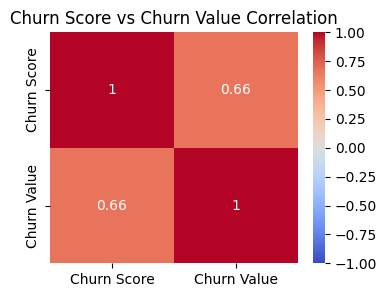

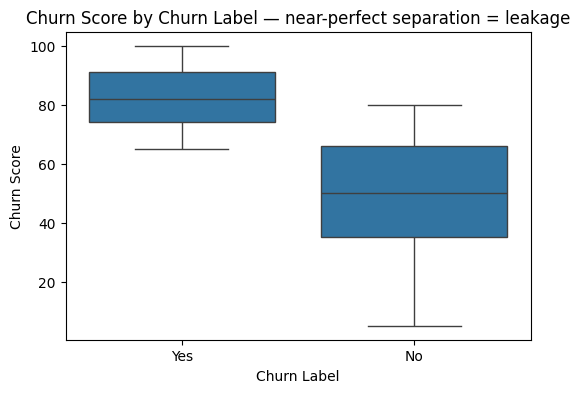

Churn Label                                Yes
Churn Reason                                  
Attitude of service provider               135
Attitude of support person                 192
Competitor had better devices              130
Competitor made better offer               140
Competitor offered higher download speeds  189
Competitor offered more data               162
Deceased                                     6
Don't know                                 154
Extra data charges                          57
Lack of affordable download/upload speed    44
Lack of self-service on Website             88
Limited range of services                   44
Long distance charges                       44
Moved                                       53
Network reliability                        103
Poor expertise of online support            19
Poor expertise of phone support             20
Price too high                              98
Product dissatisfaction                    102
Service dissa

In [44]:
# 1. Churn Score vs Churn Value (numeric-numeric) — correlation heatmap works directly
plt.figure(figsize=(4, 3))
sns.heatmap(df[['Churn Score', 'Churn Value']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Churn Score vs Churn Value Correlation')
plt.show()

# 2. Churn Score distribution split by Churn Label — shows the score is basically a proxy for the label
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn Label', y='Churn Score')
plt.title('Churn Score by Churn Label — near-perfect separation = leakage')
plt.show()

# 3. Churn Reason vs Churn Label — crosstab, since Reason only exists for churned customers
reason_crosstab = pd.crosstab(df['Churn Reason'], df['Churn Label'])
print(reason_crosstab)

**Observation:** The Churn value, label, score are inter-related and leads to data leak in the model training.

In [45]:
# Exclude constant cols + leakage cols + IDs (not useful visually)
exclude = constant_cols + ['Churn Score', 'Churn Reason', 'CustomerID', 'Churn Label']
plot_cols = [c for c in df.columns if c not in exclude]

# Split numeric vs categorical
numeric_cols = df[plot_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df[plot_cols].select_dtypes(include=['object']).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'CLTV']
Categorical: ['City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']


## Visualize data spread

In [46]:
# Separate categorical into plottable (low cardinality) vs skip (high cardinality)
CARDINALITY_THRESHOLD = 10
plottable_cat = [c for c in categorical_cols if df[c].nunique() <= CARDINALITY_THRESHOLD]
skipped_cat = [c for c in categorical_cols if df[c].nunique() > CARDINALITY_THRESHOLD]

print("Plotting categorical:", plottable_cat)
print("Skipping (high cardinality):", skipped_cat)

Plotting categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Skipping (high cardinality): ['City', 'Lat Long', 'Total Charges']


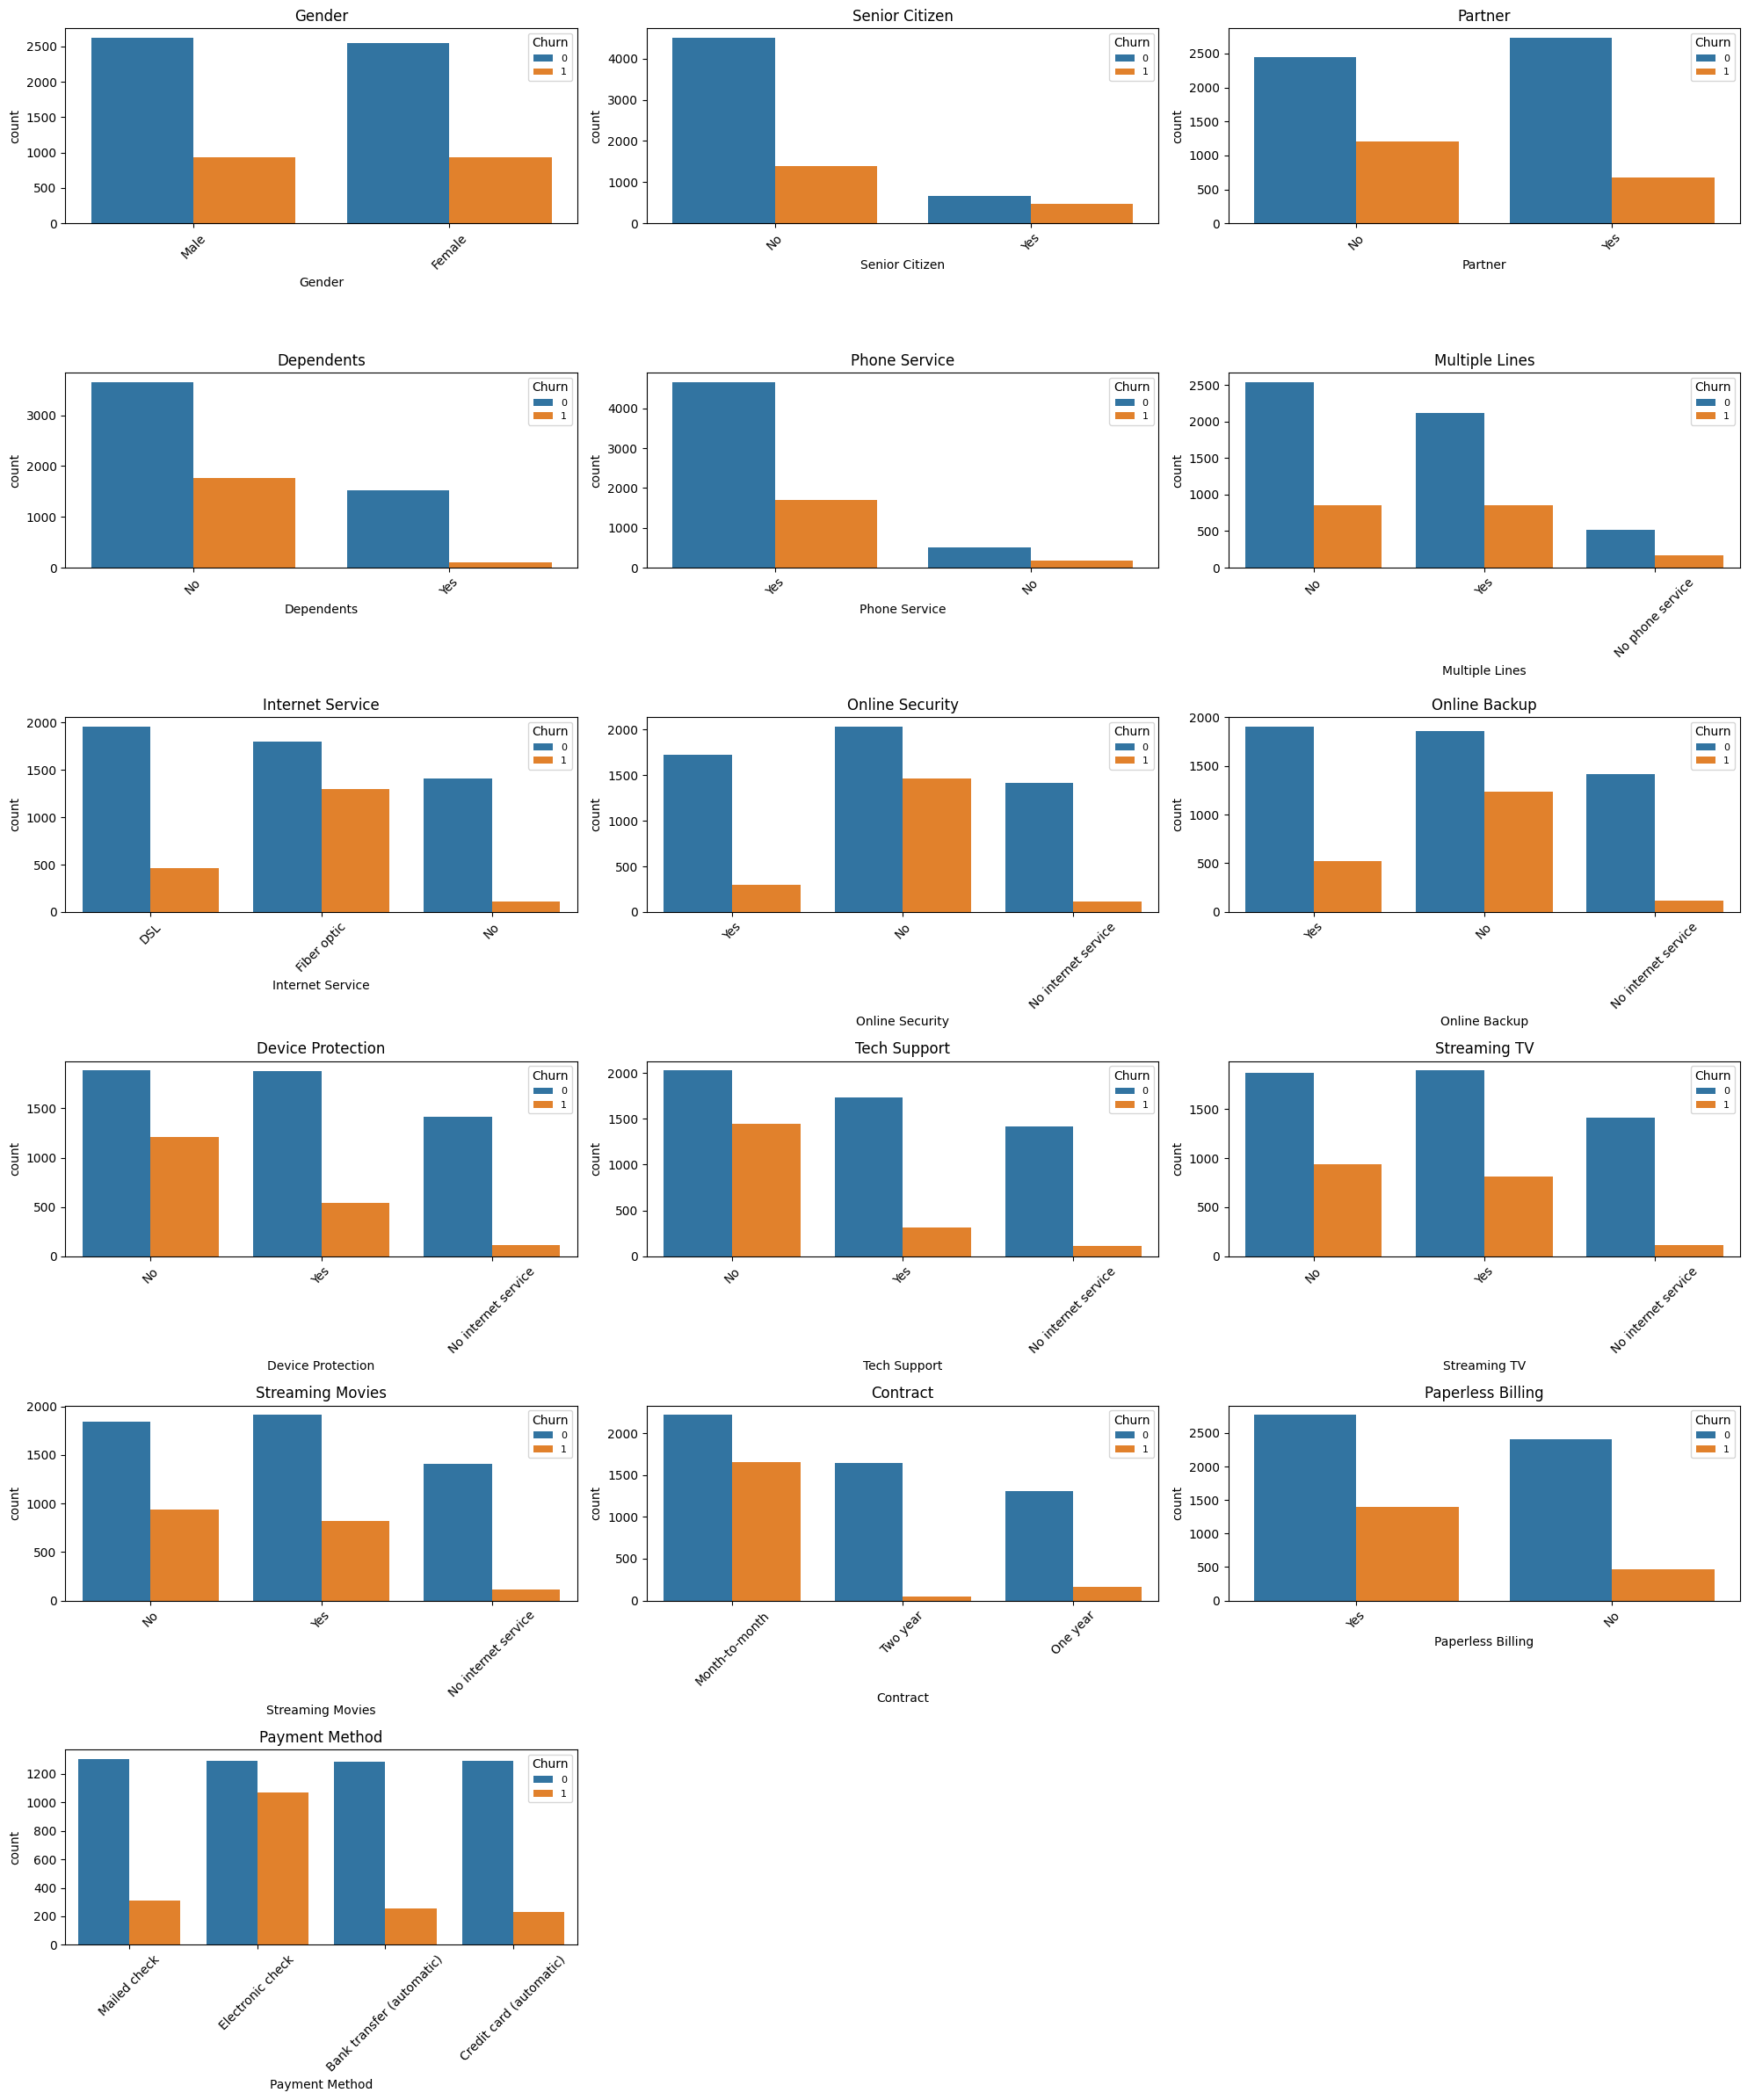

In [55]:
categorical_to_plot = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
                        'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
                        'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
                        'Contract', 'Paperless Billing', 'Payment Method']

cols = 3
rows = math.ceil(len(categorical_to_plot) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_to_plot):
    sns.countplot(data=df, x=col, hue='Churn Value', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Graph observations (count plots split by Churn Value)

- **Contract**: Cleanest signal in the dataset. Month-to-month has by far the highest churn volume; 
  Two-year shows almost no churn (thin orange sliver). Monotonic relationship — churn drops sharply 
  as contract length increases.
- **Internet Service**: Fiber optic shows a visibly higher churn proportion than DSL, despite being 
  the "better" tech — likely tied to price rather than service quality (cross-check against Monthly Charges).
- **Payment Method**: Electronic check stands out with a visibly larger churn share than the other 
  three methods, which look roughly similar to each other.
- **Partner / Dependents**: Customers with No partner / No dependents show consistently higher churn — 
  likely tied to lower switching cost (no shared household service to coordinate).
- **Online Security / Tech Support**: "No" customers churn much more than "Yes" customers. Possible 
  confound with tenure (new customers haven't opted into add-ons yet) — don't over-claim causality.
- **Gender / Phone Service**: Visually near-identical bar proportions across categories — no apparent signal.
- **Structural pattern**: Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, 
  Streaming Movies all carry a third category "No internet service" — this is fully determined by 
  Internet Service == 'No', not an independent signal. Same for Multiple Lines' "No phone service", 
  tied to Phone Service. Flagged for encoding-time cleanup (collapse into "No" to avoid redundant/
  correlated dummy columns).

In [58]:
# Churn RATE per category, not raw count
for col in categorical_to_plot:
    rate = df.groupby(col)['Churn Value'].mean().sort_values(ascending=False)
    print(f"\n{col}:\n{rate}")


Gender:
Gender
Female    0.269209
Male      0.261603
Name: Churn Value, dtype: float64

Senior Citizen:
Senior Citizen
Yes    0.416813
No     0.236062
Name: Churn Value, dtype: float64

Partner:
Partner
No     0.329580
Yes    0.196649
Name: Churn Value, dtype: float64

Dependents:
Dependents
No     0.325517
Yes    0.065151
Name: Churn Value, dtype: float64

Phone Service:
Phone Service
Yes    0.267096
No     0.249267
Name: Churn Value, dtype: float64

Multiple Lines:
Multiple Lines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn Value, dtype: float64

Internet Service:
Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn Value, dtype: float64

Online Security:
Online Security
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn Value, dtype: float64

Online Backup:
Online Backup
No                     0.399288
Yes                    

### Feature strength ranking (churn rate spread across categories)

**Strong (>20pt spread):** Contract, Payment Method, Internet Service, Online Security, Tech Support, 
Online Backup, Device Protection, Dependents, Senior Citizen

**Moderate (10–20pt spread):** Partner, Paperless Billing

**Weak / near-noise (<5pt spread):** Gender, Phone Service, Multiple Lines, Streaming TV, Streaming Movies

In [63]:
# True continuous numeric features (excludes target, excludes geo/ID columns)
true_continuous = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Rows with NaN after conversion:", df['Total Charges'].isna().sum())
print("Rows with Tenure Months == 0:", (df['Tenure Months'] == 0).sum())
# these two counts should match — confirms the NaNs are exactly the new-signup blanks

df['Total Charges'] = df['Total Charges'].fillna(0)

Rows with NaN after conversion: 0
Rows with Tenure Months == 0: 11


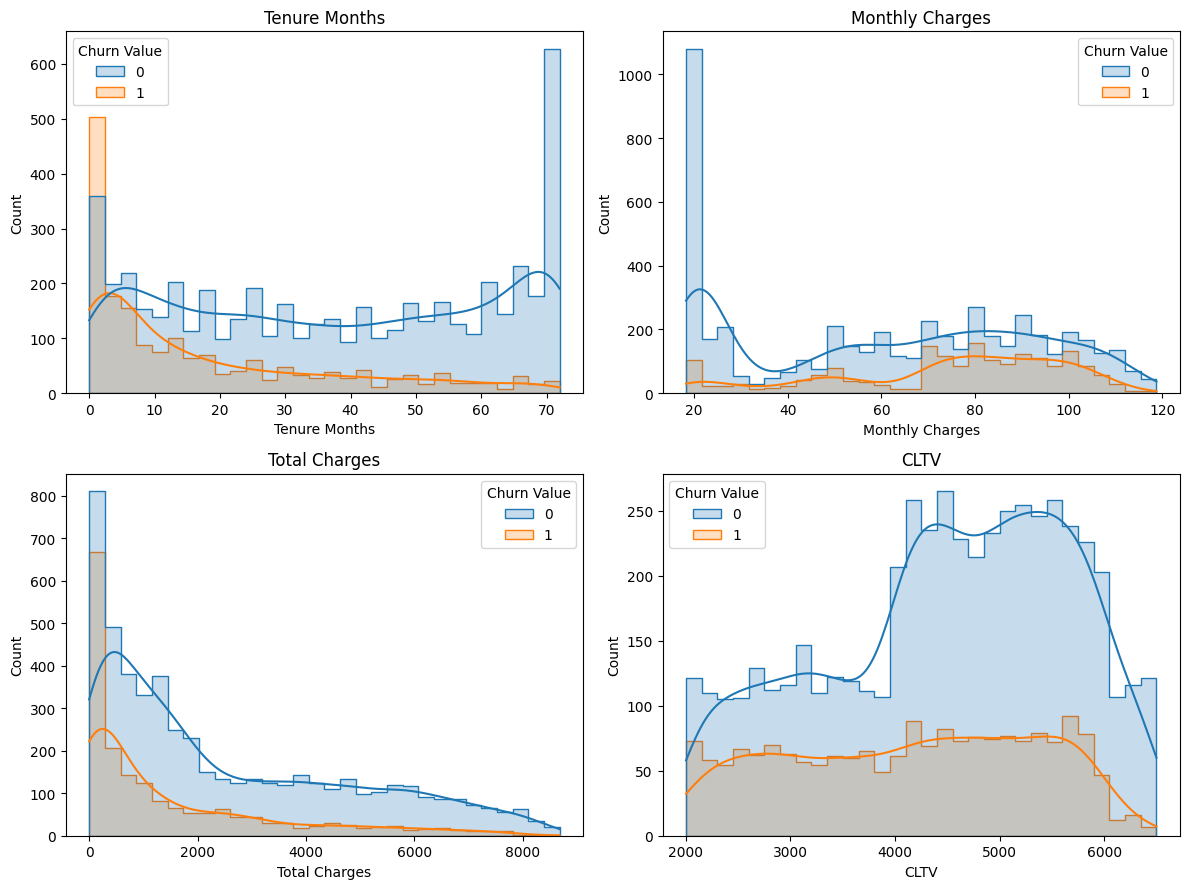

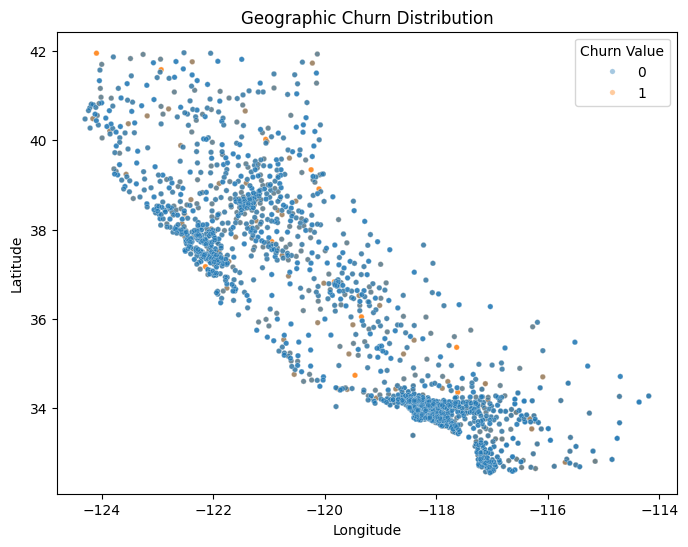

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(true_continuous):
    sns.histplot(data=df, x=col, hue='Churn Value', kde=True, ax=axes[i], bins=30, element='step')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Geo scatter — separate plot type since lat/long is spatial, not distributional
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Churn Value', alpha=0.4, s=15)
plt.title('Geographic Churn Distribution')
plt.show()

In [67]:
# --- Numeric summary stats, reshaped into a clean table ---
numeric_summary = df.groupby('Churn Value')[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']].agg(['mean', 'median', 'std']).round(2)

# Flatten the multi-index columns and pivot into a readable format
summary_clean = numeric_summary.T.reset_index()
summary_clean.columns = ['Feature', 'Stat', 'Not Churned (0)', 'Churned (1)']
summary_clean = summary_clean.sort_values(['Feature', 'Stat'])

print(summary_clean.to_string(index=False))

        Feature   Stat  Not Churned (0)  Churned (1)
           CLTV   mean          4490.92      4149.41
           CLTV median          4620.00      4238.00
           CLTV    std          1167.70      1189.37
Monthly Charges   mean            61.27        74.44
Monthly Charges median            64.43        79.65
Monthly Charges    std            31.09        24.67
  Tenure Months   mean            37.57        17.98
  Tenure Months median            38.00        10.00
  Tenure Months    std            24.11        19.53
  Total Charges   mean          2549.91      1531.80
  Total Charges median          1679.52       703.55
  Total Charges    std          2329.95      1890.82
